### **Import Required Libraries**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/online_retail.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom


### **Understand Dataset & Overview**

In [3]:
print("Dataset Features:\n",df.columns)
print("\nDataset Shape:\n",df.shape)
print("\nStatistics Information:\n", df.describe())
print("\n Information of Dataset:\n", df.info())

Dataset Features:
 Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

Dataset Shape:
 (525461, 8)

Statistics Information:
             Quantity          Price    Customer ID
count  525461.000000  525461.000000  417534.000000
mean       10.337667       4.688834   15360.645478
std       107.424110     146.126914    1680.811316
min     -9600.000000  -53594.360000   12346.000000
25%         1.000000       1.250000   13983.000000
50%         3.000000       2.100000   15311.000000
75%        10.000000       4.210000   16799.000000
max     19152.000000   25111.090000   18287.000000
<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  str    
 1   StockCode    525461 non-null  str    
 2   Description  522533 non-null  str    
 3   Quantity     

### **Data Cleaning**

In [ ]:
print("Check Duplicate:\n", df.duplicated().sum())
print("\nMissing Value:\n", df.isnull().sum())

Check Duplicate:
 6865

Missing Value:
 Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [13]:
# Drop Duplicated
df = df.drop_duplicates()

In [7]:
# Drop the row where Customer ID is missing
df = df.dropna(subset=['Customer ID'])

# Fix the datatype
df['Customer ID'] = df['Customer ID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [8]:
# Handle cancelled/returned orders
df['Invoice'] = df['Invoice'].astype(str)
cancelled = df[df['Invoice'].str.startswith('C')]
print(cancelled.shape)

(9839, 8)


In [9]:
# Handle negative/zero Quantity and Price rows separately
df[(df['Quantity'] <= 0) | (df['Price'] <= 0)].shape

(9870, 8)

In [14]:
df = df[~df['Invoice'].str.startswith('C')]

In [15]:
df[(df['Quantity'] <= 0) | (df['Price'] <= 0)].shape

(31, 8)

In [17]:
df[(df['Quantity'] <= 0) | (df['Price'] <= 0)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.0,12417,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,0.0,16858,United Kingdom


In [18]:
# Price = 0 so we drop them
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(df.shape)

(400916, 8)


In [20]:
# Verify Cleaning part
# 1. No missing values left anywhere
print(df.isnull().sum())

# 2. No duplicates left
print(df.duplicated().sum())

# 3. No cancellations left
print(df[df['Invoice'].str.startswith('C')].shape)

# 4. No negative/zero Quantity or Price left
print(df[(df['Quantity'] <= 0) | (df['Price'] <= 0)].shape)

# 5. Confirm dtypes are correct
print(df.dtypes)

# 6. Reset the index (important after all these row drops)
df = df.reset_index(drop=True)

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64
0
(0, 8)
(0, 8)
Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID             int64
Country                   str
dtype: object


In [22]:
df.sort_values('Quantity', ascending=False).head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
62586,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,13902,Denmark
90458,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,13902,Denmark
90456,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,13902,Denmark
90459,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.10,13902,Denmark
90457,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.10,13902,Denmark
96849,502269,21981,PACK OF 12 WOODLAND TISSUES,10000,2010-03-23 15:36:00,0.25,17940,United Kingdom
96846,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,2010-03-23 15:36:00,0.25,17940,United Kingdom
96847,502269,21982,PACK OF 12 SUKI TISSUES,10000,2010-03-23 15:36:00,0.25,17940,United Kingdom
96848,502269,21980,PACK OF 12 RED SPOTTY TISSUES,10000,2010-03-23 15:36:00,0.25,17940,United Kingdom
64743,498152,85220,SMALL FAIRY CAKE FRIDGE MAGNETS,9456,2010-02-17 10:51:00,0.30,13902,Denmark


In [23]:
df.sort_values('Price', ascending=False).head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
96834,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918,United Kingdom
273413,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063,United Kingdom
49787,496115,M,Manual,1,2010-01-29 11:04:00,8985.60,17949,United Kingdom
92827,501768,M,Manual,1,2010-03-19 11:45:00,6958.17,15760,Norway
92743,501766,M,Manual,1,2010-03-19 11:35:00,6958.17,15760,Norway
217461,517483,M,Manual,1,2010-07-29 12:29:00,3610.50,12737,France
273443,524162,M,Manual,1,2010-09-27 16:18:00,2769.90,14063,United Kingdom
322976,529356,M,Manual,1,2010-10-28 09:44:00,2736.16,14156,EIRE
302449,527258,M,Manual,1,2010-10-15 12:40:00,2667.88,15202,United Kingdom
286377,525498,M,Manual,1,2010-10-05 16:47:00,2545.85,14156,EIRE


In [24]:
df = df[df['StockCode'] != 'M']
print(df.shape)

(400496, 8)


In [25]:
df.sort_values('Price', ascending=False).head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
357739,533162,POST,POSTAGE,1,2010-11-16 14:29:00,850.00,12357,Switzerland
47511,495802,ADJUST,Adjustment by john on 26/01/2010 17,1,2010-01-26 17:28:00,387.54,12748,United Kingdom
186782,513566,ADJUST2,Adjustment by Peter on Jun 25 2010,1,2010-06-25 14:15:00,358.47,17364,United Kingdom
47489,495755,ADJUST,Adjustment by john on 26/01/2010 16,1,2010-01-26 16:29:00,342.80,14413,United Kingdom
222083,518052,POST,POSTAGE,1,2010-08-04 11:38:00,334.88,12748,United Kingdom
113294,504193,POST,POSTAGE,1,2010-04-12 10:10:00,306.00,12481,Germany
186781,513564,ADJUST2,Adjustment by Peter on Jun 25 2010,1,2010-06-25 14:15:00,300.13,17050,United Kingdom
239501,520204,22656,VINTAGE BLUE KITCHEN CABINET,1,2010-08-24 16:08:00,295.00,16985,United Kingdom
220134,517766,22656,VINTAGE BLUE KITCHEN CABINET,1,2010-08-02 11:25:00,295.00,14427,United Kingdom
236591,519887,22655,VINTAGE RED KITCHEN CABINET,1,2010-08-22 12:03:00,295.00,18260,United Kingdom


In [26]:
df = df[~df['StockCode'].isin(['POST', 'ADJUST', 'ADJUST2'])]
print(df.shape)

(399723, 8)


In [27]:
# See all non-numeric-looking StockCodes to catch anything else hiding
df[df['StockCode'].str.contains('[A-Za-z]', regex=True)]['StockCode'].value_counts()

StockCode
85123A    3107
85099B    1730
82494L    1021
85099F     885
85099C     826
          ... 
90127A       1
37477C       1
90142D       1
90011A       1
79151B       1
Name: count, Length: 1289, dtype: int64

In [28]:
# Make sure none of the known bad codes remain
df[df['StockCode'].isin(['POST', 'ADJUST', 'ADJUST2', 'M', 'TEST001', 'TEST002', 'D', 'DOT', 'BANK CHARGES', 'C2', 'CRUK'])]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
6560,490127,C2,CARRIAGE,1,2009-12-03 18:13:00,50.0,14156,EIRE
11005,490542,C2,CARRIAGE,1,2009-12-07 09:42:00,50.0,14911,EIRE
13670,490948,BANK CHARGES,Bank Charges,1,2009-12-08 14:29:00,15.0,16805,United Kingdom
14240,490998,C2,CARRIAGE,1,2009-12-08 17:24:00,50.0,16253,United Kingdom
15889,491160,C2,CARRIAGE,1,2009-12-10 10:29:00,50.0,14911,EIRE
...,...,...,...,...,...,...,...,...
389853,536779,BANK CHARGES,Bank Charges,1,2010-12-02 15:08:00,15.0,15823,United Kingdom
395015,537368,C2,CARRIAGE,1,2010-12-06 12:40:00,50.0,14911,EIRE
395336,537378,C2,CARRIAGE,1,2010-12-06 13:06:00,50.0,14911,EIRE
399513,537963,C2,CARRIAGE,1,2010-12-09 11:30:00,50.0,13369,United Kingdom


In [30]:
df = df[~df['StockCode'].isin(['C2', 'BANK CHARGES'])]
df = df.reset_index(drop=True)
print(df.shape)

(399583, 8)


In [31]:
df[df['StockCode'].isin(['POST', 'ADJUST', 'ADJUST2', 'M', 'TEST001', 'TEST002', 'D', 'DOT', 'BANK CHARGES', 'C2', 'CRUK'])]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
20680,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.50,12346,United Kingdom
20922,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.50,12346,United Kingdom
20923,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.50,12346,United Kingdom
27550,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.50,12346,United Kingdom
27561,492722,TEST002,This is a test product.,1,2009-12-18 10:55:00,1.00,12346,United Kingdom
30213,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346,United Kingdom
30214,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346,United Kingdom
36600,494450,TEST001,This is a test product.,5,2010-01-14 13:50:00,4.50,12346,United Kingdom
43385,495295,TEST001,This is a test product.,5,2010-01-22 13:30:00,4.50,12346,United Kingdom
112884,504188,TEST001,This is a test product.,5,2010-04-12 09:52:00,4.50,16454,United Kingdom


In [32]:
df = df[~df['StockCode'].isin(['TEST001', 'TEST002', 'D'])]
df = df.reset_index(drop=True)
print(df.shape)

(399568, 8)


In [33]:
df[df['StockCode'].isin(['POST', 'ADJUST', 'ADJUST2', 'M', 'TEST001', 'TEST002', 'D', 'DOT', 'BANK CHARGES', 'C2', 'CRUK'])]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


## **Exploratory Data Analysis**

### **Univariate Analysis**

In [37]:
df.dtypes

Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID             int64
Country                   str
dtype: object

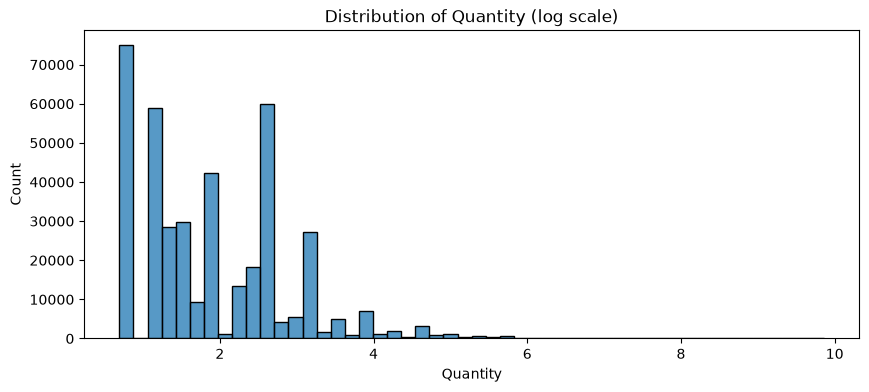

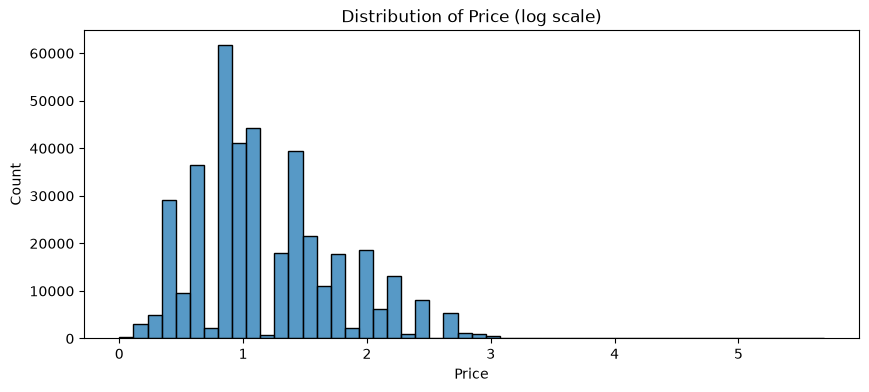

In [42]:
# Quantity Distribution
plt.figure(figsize=(10,4))
sns.histplot(np.log1p(df['Quantity']), bins=50)
plt.title('Distribution of Quantity (log scale)')
plt.show()

# Price Distribution
plt.figure(figsize=(10,4))
sns.histplot(np.log1p(df['Price']), bins=50)
plt.title('Distribution of Price (log scale)')
plt.show()

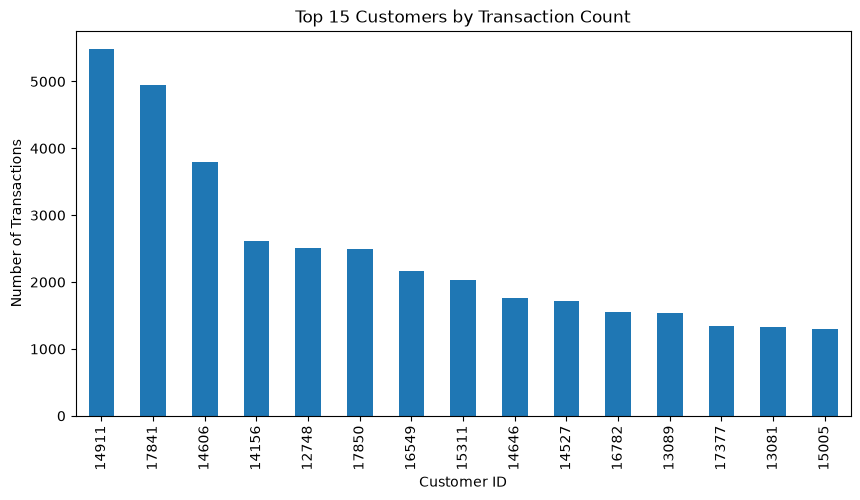

In [43]:
top_customers = df['Customer ID'].value_counts().head(15)
plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')
plt.title('Top 15 Customers by Transaction Count')
plt.xlabel('Customer ID')
plt.ylabel('Number of Transactions')
plt.show()

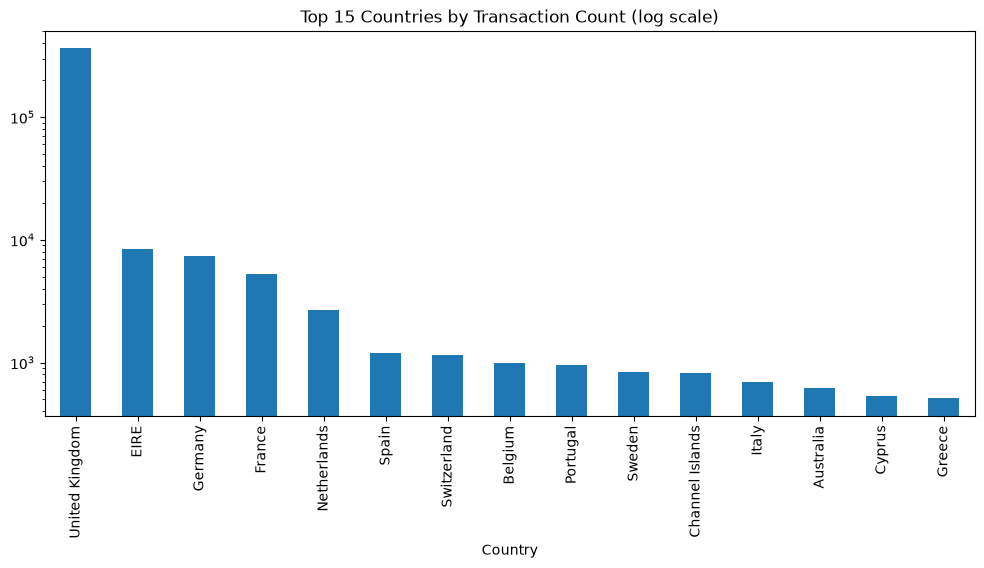

In [ ]:
# Top 15 Country
plt.figure(figsize=(12,5))
df['Country'].value_counts().head(15).plot(kind='bar')
plt.yscale('log')
plt.title('Top 15 Countries by Transaction Count (log scale)')
plt.show()

### **Bivariate Analysis**

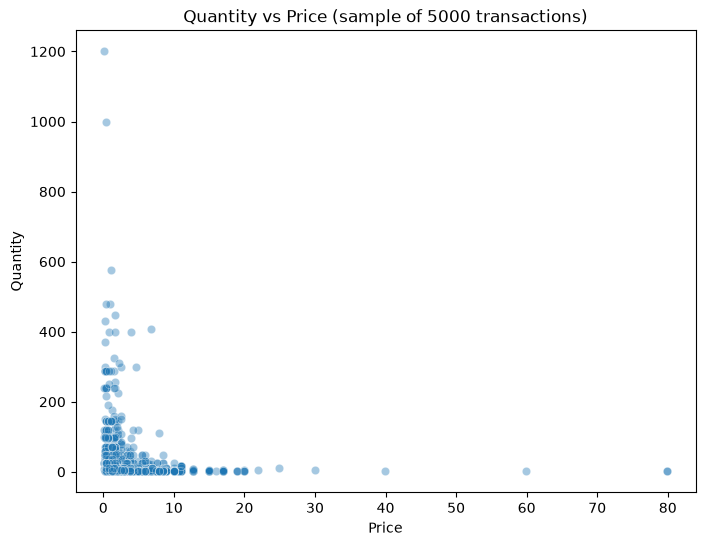

In [47]:
# Quantity vs Price Relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(5000, random_state=42), x='Price', y='Quantity', alpha=0.4)
plt.title("Quantity vs Price (sample of 5000 transactions)")
plt.show()

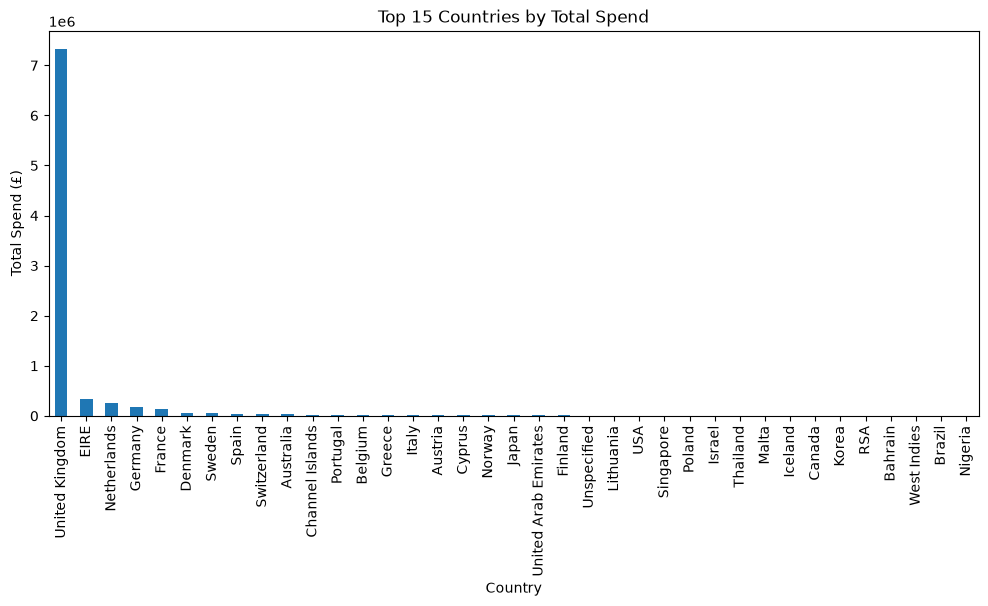

In [49]:
# Total spend by Country
df['TotalPrice'] = df['Price'] * df['Quantity']
country_spend = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
country_spend.plot(kind='bar')
plt.title('Top 15 Countries by Total Spend')
plt.ylabel('Total Spend (£)')
plt.show()

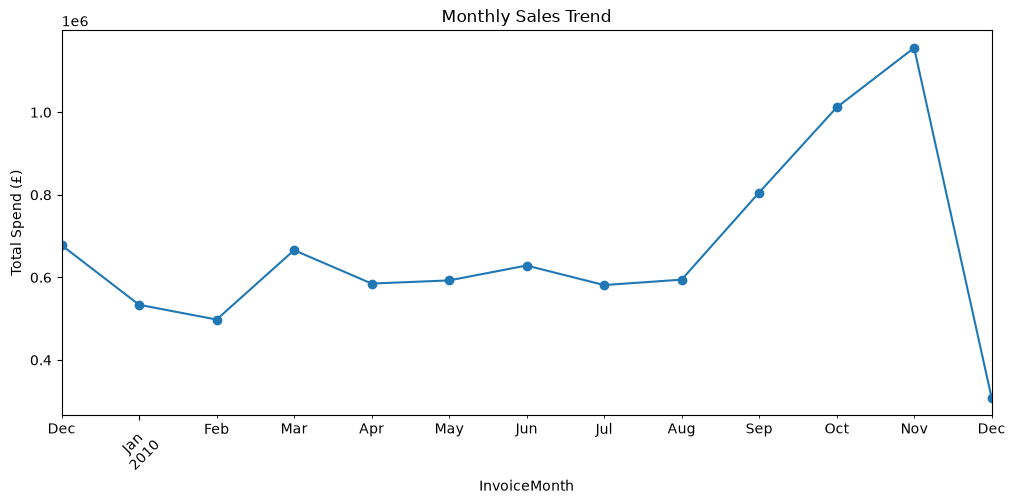

In [ ]:
# Spend trend over time
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('InvoiceMonth')['TotalPrice'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Spend (£)')
plt.xticks(rotation=45)
plt.show()

In [52]:
df[(df['Quantity'] > 1000) & (df['Price'] < 1)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,InvoiceMonth
5187,490018,21981,PACK OF 12 WOODLAND TISSUES,4320,2009-12-03 12:31:00,0.25,17940,United Kingdom,1080.0,2009-12
5188,490018,21967,PACK OF 12 SKULL TISSUES,5184,2009-12-03 12:31:00,0.25,17940,United Kingdom,1296.0,2009-12
5189,490018,21984,PACK OF 12 PINK PAISLEY TISSUES,4008,2009-12-03 12:31:00,0.25,17940,United Kingdom,1002.0,2009-12
5190,490018,21980,PACK OF 12 RED SPOTTY TISSUES,4008,2009-12-03 12:31:00,0.25,17940,United Kingdom,1002.0,2009-12
15675,491133,16014,SMALL CHINESE STYLE SCISSOR,1500,2009-12-09 16:17:00,0.32,13848,United Kingdom,480.0,2009-12
...,...,...,...,...,...,...,...,...,...,...
378726,535661,84568,GIRLS ALPHABET IRON ON PATCHES,1440,2010-11-28 11:33:00,0.17,13069,United Kingdom,244.8,2010-11
388963,536809,84950,ASSORTED COLOUR T-LIGHT HOLDER,1824,2010-12-02 16:48:00,0.55,15299,United Kingdom,1003.2,2010-12
389027,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,2010-12-02 17:38:00,0.18,16754,United Kingdom,518.4,2010-12
389541,536890,17084R,ASSORTED INCENSE PACK,1440,2010-12-03 11:48:00,0.16,14156,EIRE,230.4,2010-12


In [53]:
df[df['InvoiceMonth'] == df['InvoiceMonth'].max()]['InvoiceDate'].max()

Timestamp('2010-12-09 20:01:00')

In [54]:
# Set reference date for Recency (one day after the last transaction)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,   # Recency
    'Invoice': 'nunique',                                        # Frequency
    'TotalPrice': 'sum'                                          # Monetary
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,165,2,169.36
1,12347,3,2,1323.32
2,12348,74,1,221.16
3,12349,43,2,2221.14
4,12351,11,1,300.93


In [55]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,4285.000000,4285.000000,4285.000000,4285.000000
mean,15356.806768,90.548191,4.426138,2016.256059
std,1699.839258,96.359872,7.938017,8811.222107
min,12346.000000,1.000000,1.000000,1.550000
25%,13891.000000,18.000000,1.000000,306.640000
50%,15362.000000,52.000000,2.000000,692.240000
75%,16840.000000,136.000000,5.000000,1699.250000
max,18287.000000,374.000000,183.000000,349164.350000


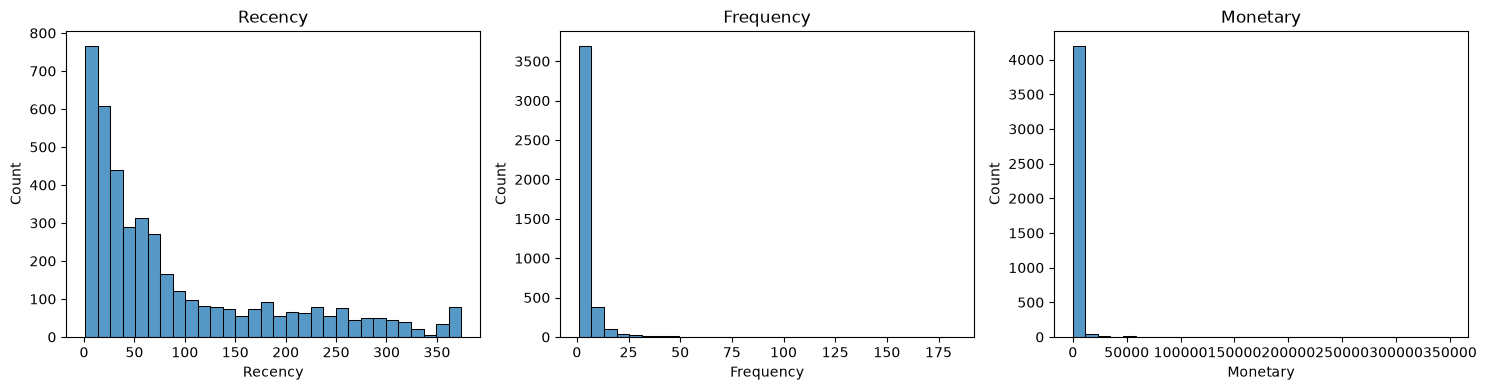

In [56]:
# Visualize RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(rfm['Recency'], bins=30, ax=axes[0])
sns.histplot(rfm['Frequency'], bins=30, ax=axes[1])
sns.histplot(rfm['Monetary'], bins=30, ax=axes[2])
axes[0].set_title('Recency')
axes[1].set_title('Frequency')
axes[2].set_title('Monetary')
plt.tight_layout()
plt.show()

### **Multivariate Analysis**

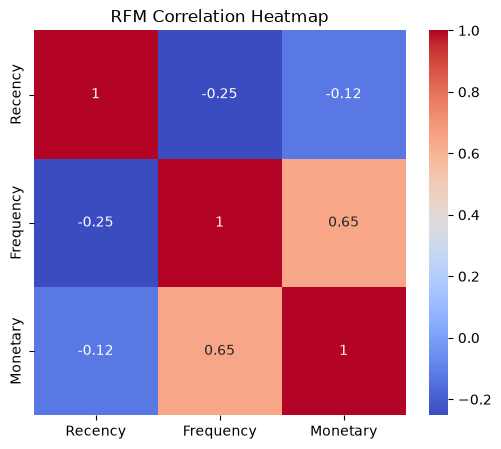

In [57]:
# Correlation between R, F, M

plt.figure(figsize=(6,5))
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary']].corr(), annot=True, cmap='coolwarm')
plt.title('RFM Correlation Heatmap')
plt.show()

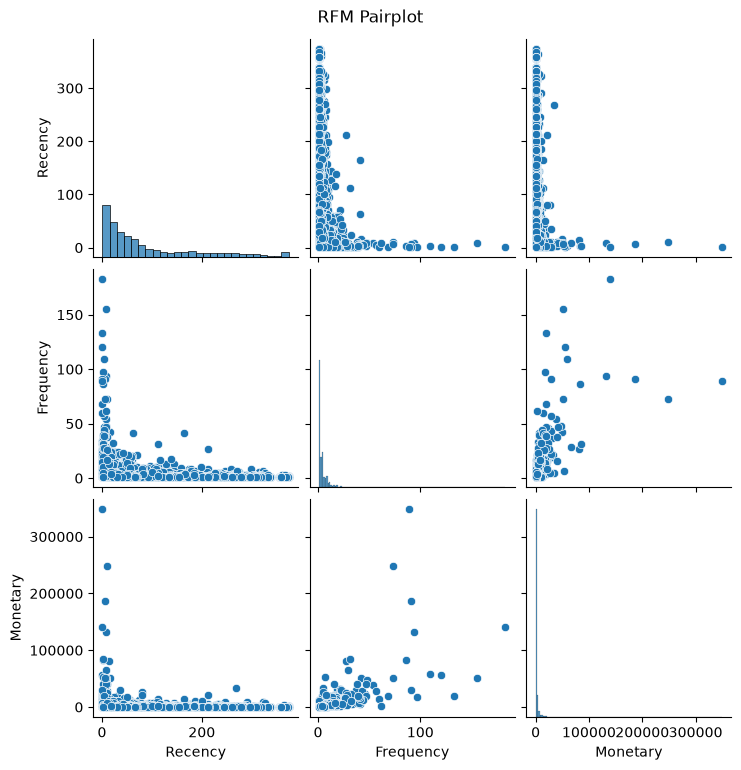

In [58]:
# Pairplot — see all 3 relationships at once
sns.pairplot(rfm[['Recency', 'Frequency', 'Monetary']])
plt.suptitle('RFM Pairplot', y=1.02)
plt.show()

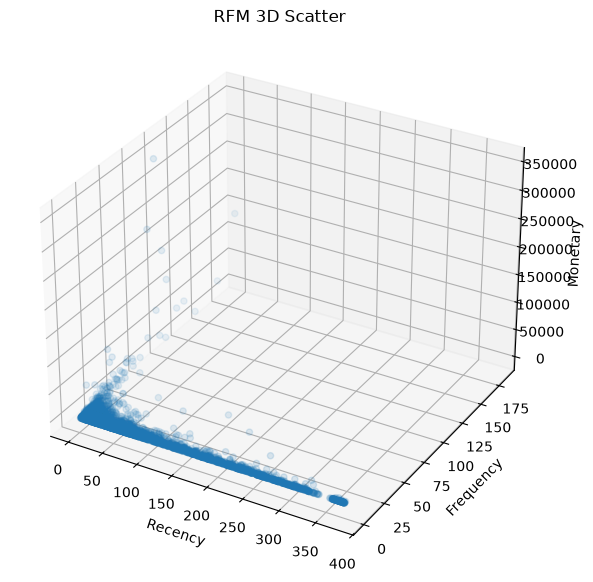

In [59]:
# 3D visualization

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], alpha=0.4)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.title('RFM 3D Scatter')
plt.show()

### **Handle Skewness**

In [60]:
rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

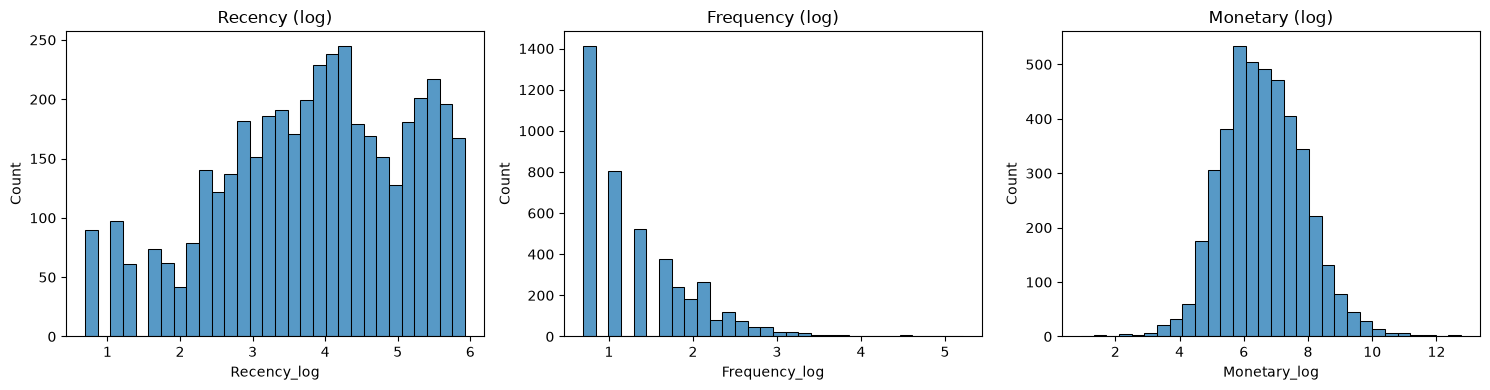

In [61]:
# Verify to check skewness

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(rfm['Recency_log'], bins=30, ax=axes[0])
sns.histplot(rfm['Frequency_log'], bins=30, ax=axes[1])
sns.histplot(rfm['Monetary_log'], bins=30, ax=axes[2])
axes[0].set_title('Recency (log)')
axes[1].set_title('Frequency (log)')
axes[2].set_title('Monetary (log)')
plt.tight_layout()
plt.show()

### **Scaling**

In [62]:
from sklearn.preprocessing import StandardScaler

features = rfm[['Recency_log', 'Frequency_log', 'Monetary_log']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])
rfm_scaled.head()

,Recency_scaled,Frequency_scaled,Monetary_scaled
0,0.972085,-0.392573,-1.148354
1,-1.896766,-0.392573,0.458107
2,0.360306,-0.981472,-0.940385
3,-0.050344,-0.392573,0.863550
4,-1.050815,-0.981472,-0.700053


### **Find optimal clusters**

In [63]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

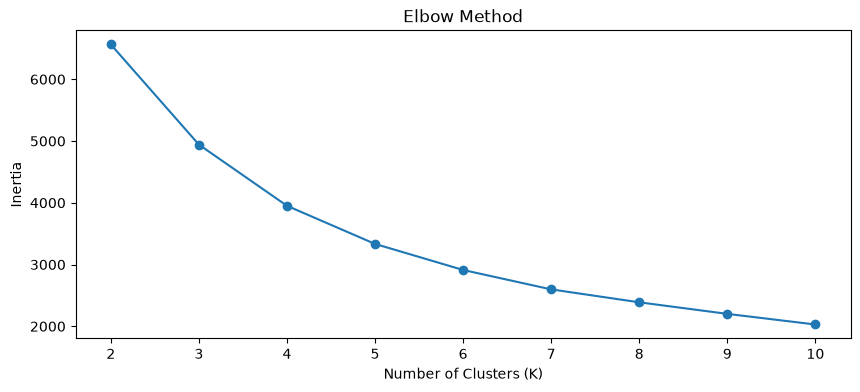

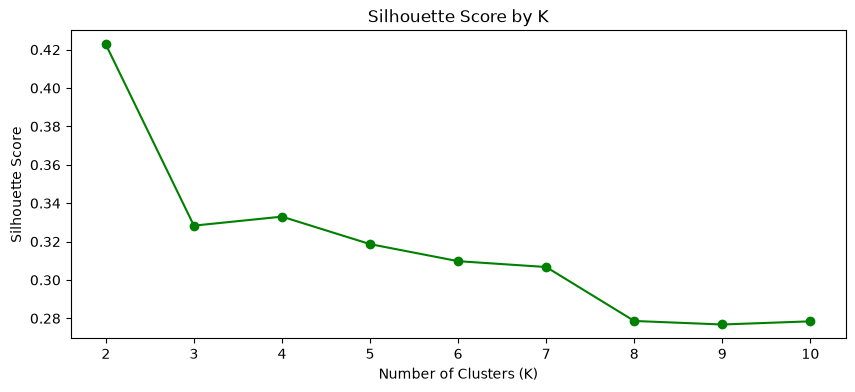

In [64]:
# Plot Elbow Method
plt.figure(figsize=(10,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(10,4))
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')
plt.show()

In [65]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log,Cluster
0,12346,165,2,169.36,5.111988,1.098612,5.137914,2
1,12347,3,2,1323.32,1.386294,1.098612,7.188654,0
2,12348,74,1,221.16,4.317488,0.693147,5.403398,2
3,12349,43,2,2221.14,3.784190,1.098612,7.706226,1
4,12351,11,1,300.93,2.484907,0.693147,5.710195,0


In [66]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_summary['Count'] = rfm['Cluster'].value_counts().sort_index()
cluster_summary

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,22.3,2.1,560.1,938
1,82.2,4.1,1786.8,1174
2,184.7,1.3,301.7,1408
3,13.8,13.5,7309.5,765


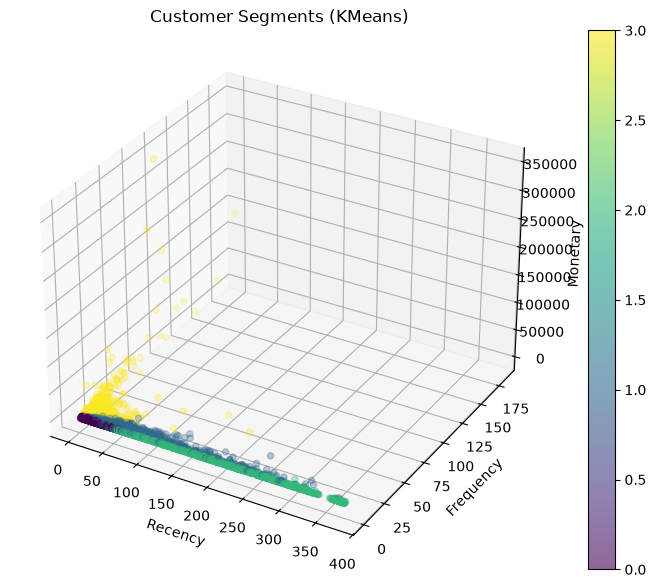

In [67]:
# KMeans Visualization
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', alpha=0.6)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.title('Customer Segments (KMeans)')
plt.colorbar(scatter)
plt.show()

In [68]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['Cluster_DBSCAN'] = dbscan.fit_predict(rfm_scaled)

print(rfm['Cluster_DBSCAN'].value_counts())

Cluster_DBSCAN
 0    2825
 1    1406
-1      54
Name: count, dtype: int64


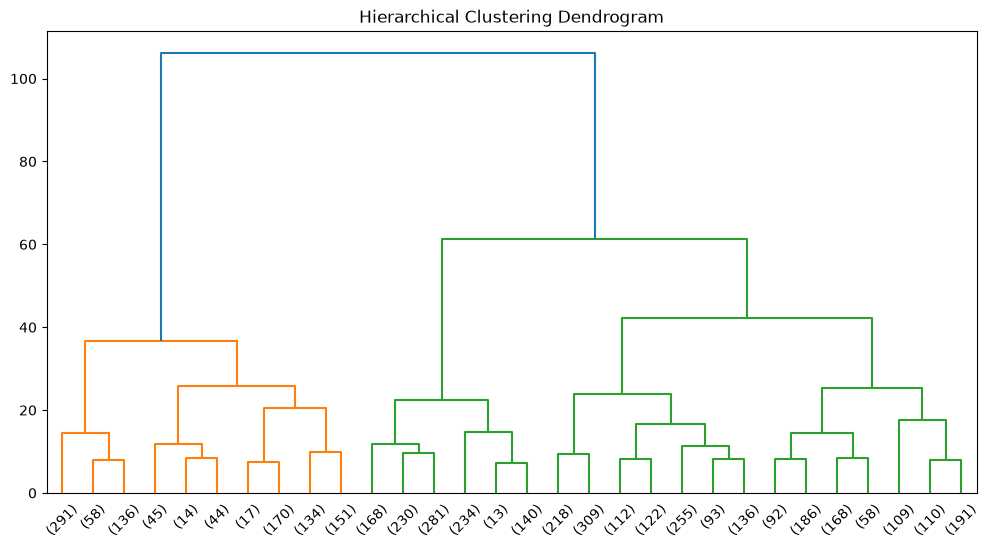

In [69]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(rfm_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

In [70]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=4)
rfm['Cluster_Hierarchical'] = hierarchical.fit_predict(rfm_scaled)

print("KMeans Silhouette:", silhouette_score(rfm_scaled, rfm['Cluster']))
print("Hierarchical Silhouette:", silhouette_score(rfm_scaled, rfm['Cluster_Hierarchical']))
# DBSCAN score only valid if it found more than 1 cluster and not all noise

KMeans Silhouette: 0.3329930581029617
Hierarchical Silhouette: 0.2692818820942466


### **Save the Best Model**

In [71]:
import joblib
import os

# Make sure models folder exists
os.makedirs('../models', exist_ok=True)

# Save the trained KMeans model
joblib.dump(kmeans_final, '../models/kmeans_model.pkl')

# Save the scaler too — need to transform NEW customer data the same way before predicting
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
